# LIBRETA DE TRABAJO

##  Analizar cuantos comentarios se repiten en la columna comments

In [8]:
#identificar cuantos strings distintos se repiten en la columna comments y mostrarlos
conteo_comentarios = df['Comments'].value_counts(dropna=False)
print("Strings  en la columna comments:")
print(conteo_comentarios)

Strings  en la columna comments:
Comments
NaN                                                                     290
Nest never observed with full clutch.                                    34
Not enough blood for isotopes.                                            7
Sexing primers did not amplify.                                           4
No blood sample obtained.                                                 2
No blood sample obtained for sexing.                                      2
Adult not sampled.                                                        1
Nest never observed with full clutch. Not enough blood for isotopes.      1
Sexing primers did not amplify. Not enough blood for isotopes.            1
Adult not sampled. Nest never observed with full clutch.                  1
No delta15N data received from lab.                                       1
Name: count, dtype: int64


Conteo de especies:
species
adelie  (pygoscelis adeliae)                 151
gentoo penguin (pygoscelis papua)            123
chinstrap penguin (pygoscelis antarctica)     68
Name: count, dtype: int64

Reparto por isla:
island
biscoe       167
dream        124
torgersen     51
Name: count, dtype: int64

island percentages:
Island
Biscoe       48.830409
Dream        36.257310
Torgersen    14.912281
Name: proportion, dtype: float64


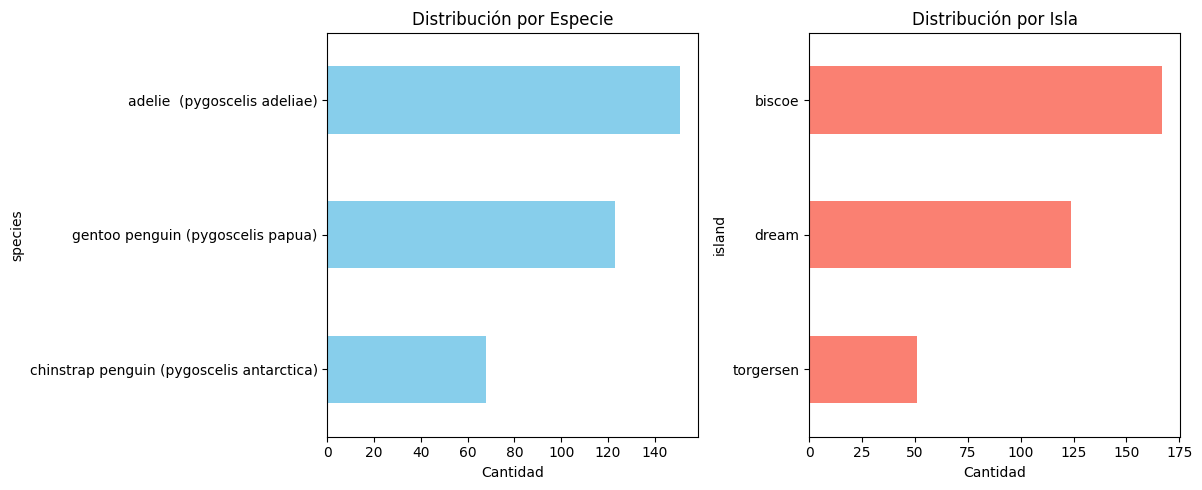

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('df_clean_penguins.csv')

conteo_especies = df['species'].value_counts()
print("Conteo de especies:")
print(conteo_especies)

conteo_isla = df['island'].value_counts()
print("\nReparto por isla:")
print(island_counts)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
conteo_especies.sort_values().plot(kind='barh', color='skyblue')
plt.title('Distribución por Especie')
plt.xlabel('Cantidad')

plt.subplot(1, 2, 2)
conteo_isla.sort_values().plot(kind='barh', color='salmon')
plt.title('Distribución por Isla')
plt.xlabel('Cantidad')

plt.tight_layout()
plt.savefig('distributciones.png')

Island_pct = df['island'].value_counts(normalize=True) * 100
print("\nisland percentages:")
print(island_pct)

1. Especies y observaciones:

Hay 3 especies identificadas en esta muestra única de pingüinos:  
Adelie: 151 observaciones.  
Chinstrap: 68 observaciones.  
Gentoo: 123 observaciones.  
La especie Adelie es, con diferencia, la más frecuente.    

2. Distribución por Islas
Los pingüinos aparecen en 3 islas del archipiélago de Anvers:  

Dream: 124 pingüinos.  
Torgersen: 51 pingüinos.  
Biscoe: 167 pingüinos.  

3. Balance de datos  

No hay un balance uniforme entre las islas; existe una clara predominancia:
Isla Dream: Concentra casi la mitad de los datos (49.5%).
Isla Torgersen: Representa el 27.4%.
Isla Biscoe: Es la que tiene menos representación con el 23.1%.

Esta diferencia sugiere que la mayoría de los individuos únicos identificados en el estudio provienen de la Isla Dream.

Valores medios por especie:
                                           culmen length (mm)  \
species                                                         
adelie  (pygoscelis adeliae)                        38.791391   
chinstrap penguin (pygoscelis antarctica)           48.833824   
gentoo penguin (pygoscelis papua)                   47.504878   

                                           culmen depth (mm)  \
species                                                        
adelie  (pygoscelis adeliae)                       18.346358   
chinstrap penguin (pygoscelis antarctica)          18.420588   
gentoo penguin (pygoscelis papua)                  14.982114   

                                           flipper length (mm)  body mass (g)  
species                                                                        
adelie  (pygoscelis adeliae)                        189.953642    3700.662252  
chinstrap penguin (pygoscelis antarctica)           195.823529    3733.088235  
gento

C:\Users\juang\AppData\Local\Temp\ipykernel_7968\1865751356.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=col, data=df, ax=axes[i], palette='viridis')
C:\Users\juang\AppData\Local\Temp\ipykernel_7968\1865751356.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=col, data=df, ax=axes[i], palette='viridis')
C:\Users\juang\AppData\Local\Temp\ipykernel_7968\1865751356.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=col, data=df, ax=axes[i], palette='viridis')
C:\Users\juang\AppData\Local

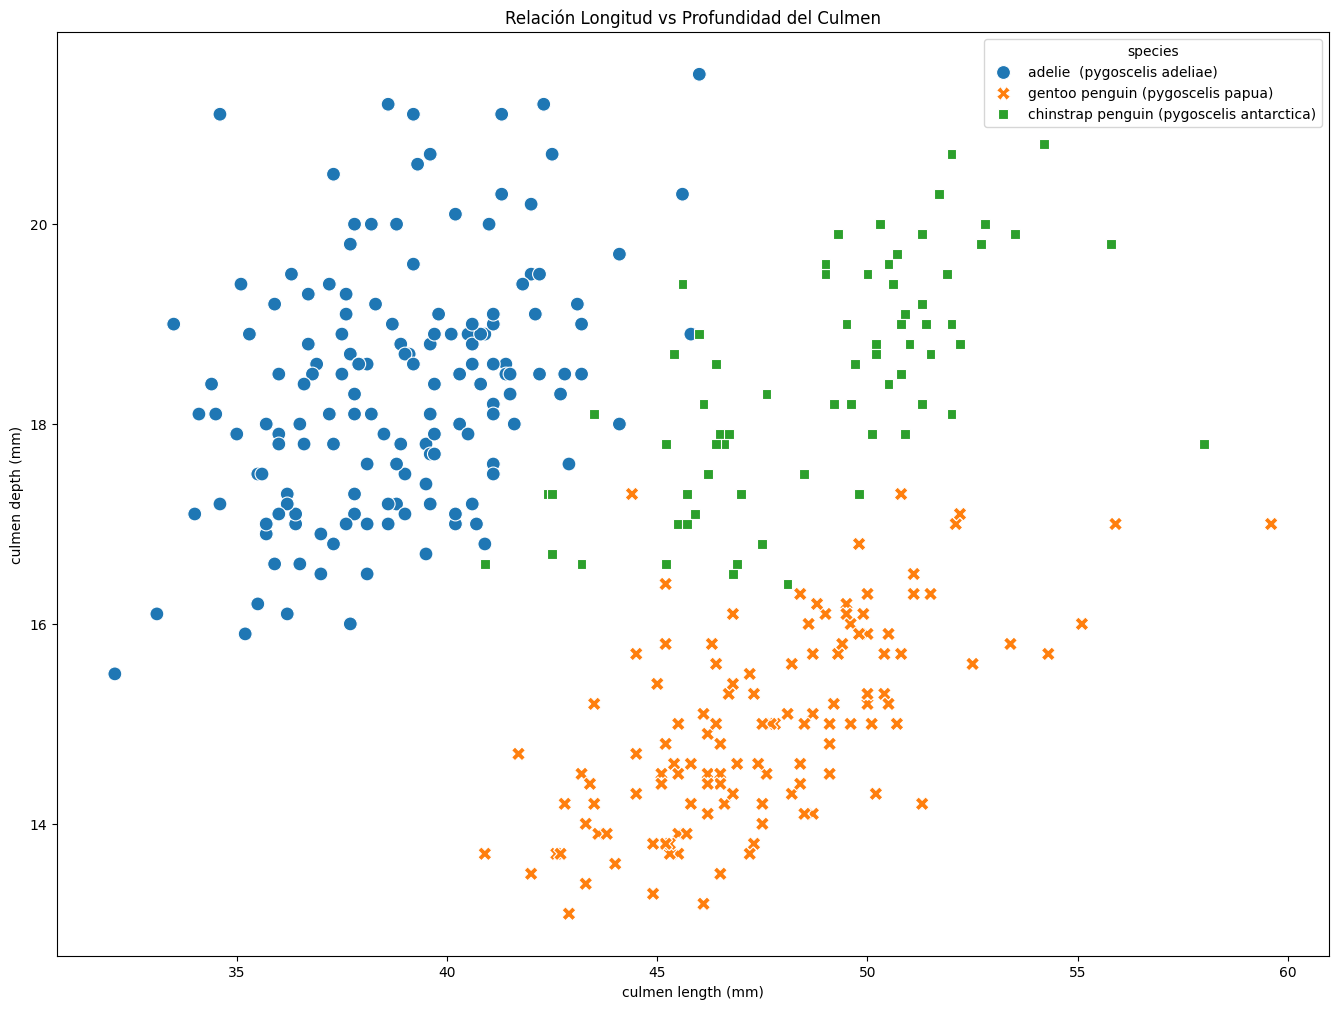

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('df_clean_penguins.csv')

features = ['culmen length (mm)', 'culmen depth (mm)', 'flipper length (mm)', 'body mass (g)']

stats = df.groupby('species')[features].mean()
print("Valores medios por especie:")
print(stats)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x='species', y=col, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('morphology_boxplots.png')

plt.clf()
sns.scatterplot(data=df, x='culmen length (mm)', y='culmen depth (mm)', hue='species', style='species', s=100)
plt.title('Relación Longitud vs Profundidad del Culmen')
plt.savefig('culmen_scatter.png')

1. Diferencias en tamaño y forma. Las especies se pueden agrupar por su físico: 
Adelie: Son los más "pequeños" en cuanto a pico. Tienen el culmen (pico) más corto (promedio de $38.8$ mm), lo que les da una apariencia de cabeza más redondeada.
Gentoo: Son los "gigantes" del grupo. Tienen las aletas más largas (aprox. 218 mm) y son significativamente más pesados (aprox 5 kg), superando por más de un kilo a las otras dos especies. Además, su pico es notablemente más delgado/fino (menor profundidad).
Chinstrap: Tienen una forma híbrida. Son similares en peso y aletas a los Adelie, pero su pico es muy largo (similar al de los Gentoo), lo que los hace destacar visualmente por tener un pico proporcionalmente grande para su cuerpo.2. 
¿Diferencias coherentes o solapamiento?
Solapamiento alto: Existe mucho solapamiento en el peso y largo de aleta entre los Adelie y Chinstrap. Si solo pesaras a un pingüino de $3.7$ kg, no sabrías cuál de los dos es.
Coherencia clara: Los Gentoo son casi totalmente distintos en masa corporal; es muy raro confundirlos con los demás por su gran tamaño.
El "Cruce" del pico: El solapamiento más interesante ocurre en el pico. Adelie y Chinstrap tienen picos de igual grosor (profundidad), pero de distinta longitud. Chinstrap y Gentoo tienen picos de igual longitud, pero distinto grosor.3.
Variable más útil para distinguir especies.
Si tuvieras que elegir una sola variable, la longitud del culmen (pico) es la más potente para separar a los Adelie de los demás. Sin embargo, para distinguir las tres especies simultáneamente, la combinación de Longitud del Culmen vs. Profundidad del Culmen es la herramienta definitiva. Al graficar estas dos variables juntas, los pingüinos se agrupan en tres "nubes" o clusters casi perfectamente separados:
Pico corto y grueso: Adelie. 
Pico largo y grueso: Chinstrap. 
Pico largo y fino: Gentoo.

Resumen de la masa corporal por especie:
                                           count         mean         std  \
species                                                                     
adelie  (pygoscelis adeliae)               151.0  3700.662252  458.566126   
chinstrap penguin (pygoscelis antarctica)   68.0  3733.088235  384.335081   
gentoo penguin (pygoscelis papua)          123.0  5076.016260  504.116237   

                                              min     25%     50%     75%  \
species                                                                     
adelie  (pygoscelis adeliae)               2850.0  3350.0  3700.0  4000.0   
chinstrap penguin (pygoscelis antarctica)  2700.0  3487.5  3700.0  3950.0   
gentoo penguin (pygoscelis papua)          3950.0  4700.0  5000.0  5500.0   

                                              max  
species                                            
adelie  (pygoscelis adeliae)               4775.0  
chinstrap penguin (pygoscelis a

C:\Users\juang\AppData\Local\Temp\ipykernel_7968\2915399564.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='species', y='body mass (g)', data=df, palette='Set2', inner="quartile")


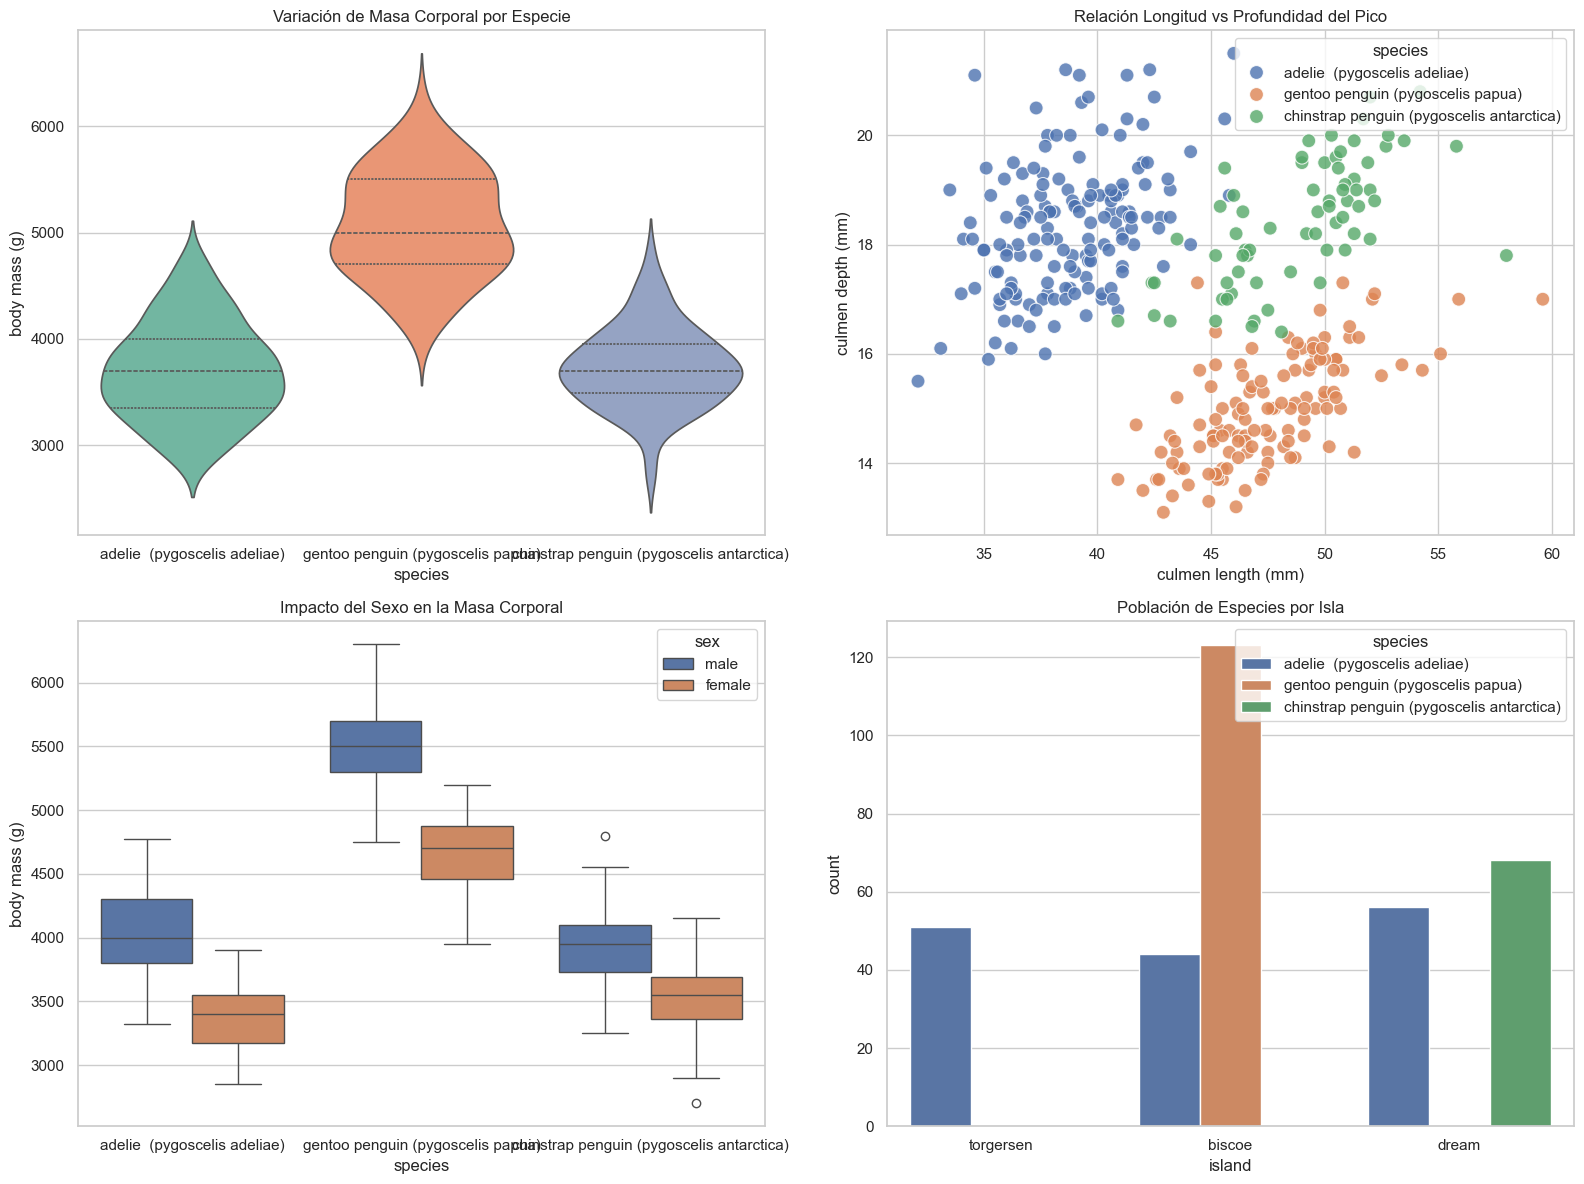

<Figure size 640x480 with 0 Axes>

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('df_clean_penguins.csv')

mass_summary = df.groupby('species')['body mass (g)'].describe()
print("Resumen de la masa corporal por especie:")
print(mass_summary)

corr_culmen = df.groupby('species')[['culmen length (mm)', 'culmen depth (mm)']].corr().iloc[0::2, 1]
print("\nCorrelación entre la longitud del culmen y la profundidad por especie:")
print(corr_culmen)


df_sex = df.dropna(subset=['sex'])
sex_mass = df_sex.groupby(['species', 'sex'])['body mass (g)'].mean().unstack()
print("\nMasa corporal media por especie y sexo:")
print(sex_mass)

adelie_islands = df[df['species'] == 'Adelie'].groupby('island')[['body mass (g)', 'culmen length (mm)']].mean()
print("\nAdelie penguin metrics across different islands:")
print(adelie_islands)

plt.figure(figsize=(16, 12))


# 1. Variación de Masa
plt.subplot(2, 2, 1)
sns.violinplot(x='species', y='body mass (g)', data=df, palette='Set2', inner="quartile")
plt.title('Variación de Masa Corporal por Especie')

# 2. Relación del Pico
plt.subplot(2, 2, 2)
sns.scatterplot(x='culmen length (mm)', y='culmen depth (mm)', hue='species', data=df, s=100, alpha=0.8)
plt.title('Relación Longitud vs Profundidad del Pico')

# 3. Dimorfismo Sexual
plt.subplot(2, 2, 3)
sns.boxplot(x='species', y='body mass (g)', hue='sex', data=df_sex)
plt.title('Impacto del Sexo en la Masa Corporal')

# 4. Distribución Geográfica
plt.subplot(2, 2, 4)
sns.countplot(x='island', hue='species', data=df)
plt.title('Población de Especies por Isla')

plt.tight_layout()
plt.show() # O plt.savefig('analisis_completo.png')




plt.tight_layout()
plt.savefig('analisis comparativo.png')

1. Variación de la masa corporal por especie:
Existe una diferencia muy marcada, especialmente con la especie Gentoo.  
Gentoo: Son los más grandes, con un promedio de 5.03 kg. Son una "clase aparte" en cuanto a tamaño.     
Adelie y Chinstrap: Son casi idénticos en peso, con promedios de 3.71 kg y 3.72 kg respectivamente. No podrías diferenciarlos solo usando una báscula.  
2. Relación entre longitud y profundidad del pico.
Sí hay relación, pero varía según la especie: En los Gentoo y Chinstrap, hay una correlación fuerte, a medida que el pico es más largo, también tiende a ser más profundo (grueso).En los Adelie, la relación es débil, la longitud del pico no predice muy bien su grosor; sus picos tienden a ser más uniformemente cortos y gruesos.
3. El sexo y su influencia en el tamaño.   
El sexo es un factor determinante en las tres especies. En todos los casos, los machos son significativamente más grandes y pesados que las hembras. En promedio, un macho pesa entre 400g y 700g más que una hembra de su misma especie. Esta diferencia es tan constante que el peso es una de las mejores métricas para estimar el sexo cuando no se tiene un análisis de ADN.
4. Diferencias entre islas (para la misma especie) Los pingüinos Adelie, ya que es la única especie que está presente en las tres islas (Biscoe, Dream y Torgersen), para ver si el entorno influye en su tamaño: Uniformidad sorprendente: No hay diferencias drásticas. Un Adelie en la isla Biscoe mide y pesa casi lo mismo que uno en Torgersen. Ligera tendencia: Los pingüinos de la Isla Biscoe son ligeramente más pesados, frente a los de la Isla Dream, pero la diferencia es mínima y podría deberse al azar del muestreo.
Conclusión: La especie es morfológicamente muy estable a través de las distintas islas.

linea de Graciela